In [10]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier # Example model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target (species)
feature_names = iris.feature_names
target_names = iris.target_names

In [12]:
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
# Map numerical target to actual species names for better readability
df['species_name'] = df['species'].apply(lambda x: target_names[x])

In [13]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [14]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int32  
 5   species_name       150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB


In [15]:
print("\nSpecies Distribution:")
print(df['species_name'].value_counts())


Species Distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


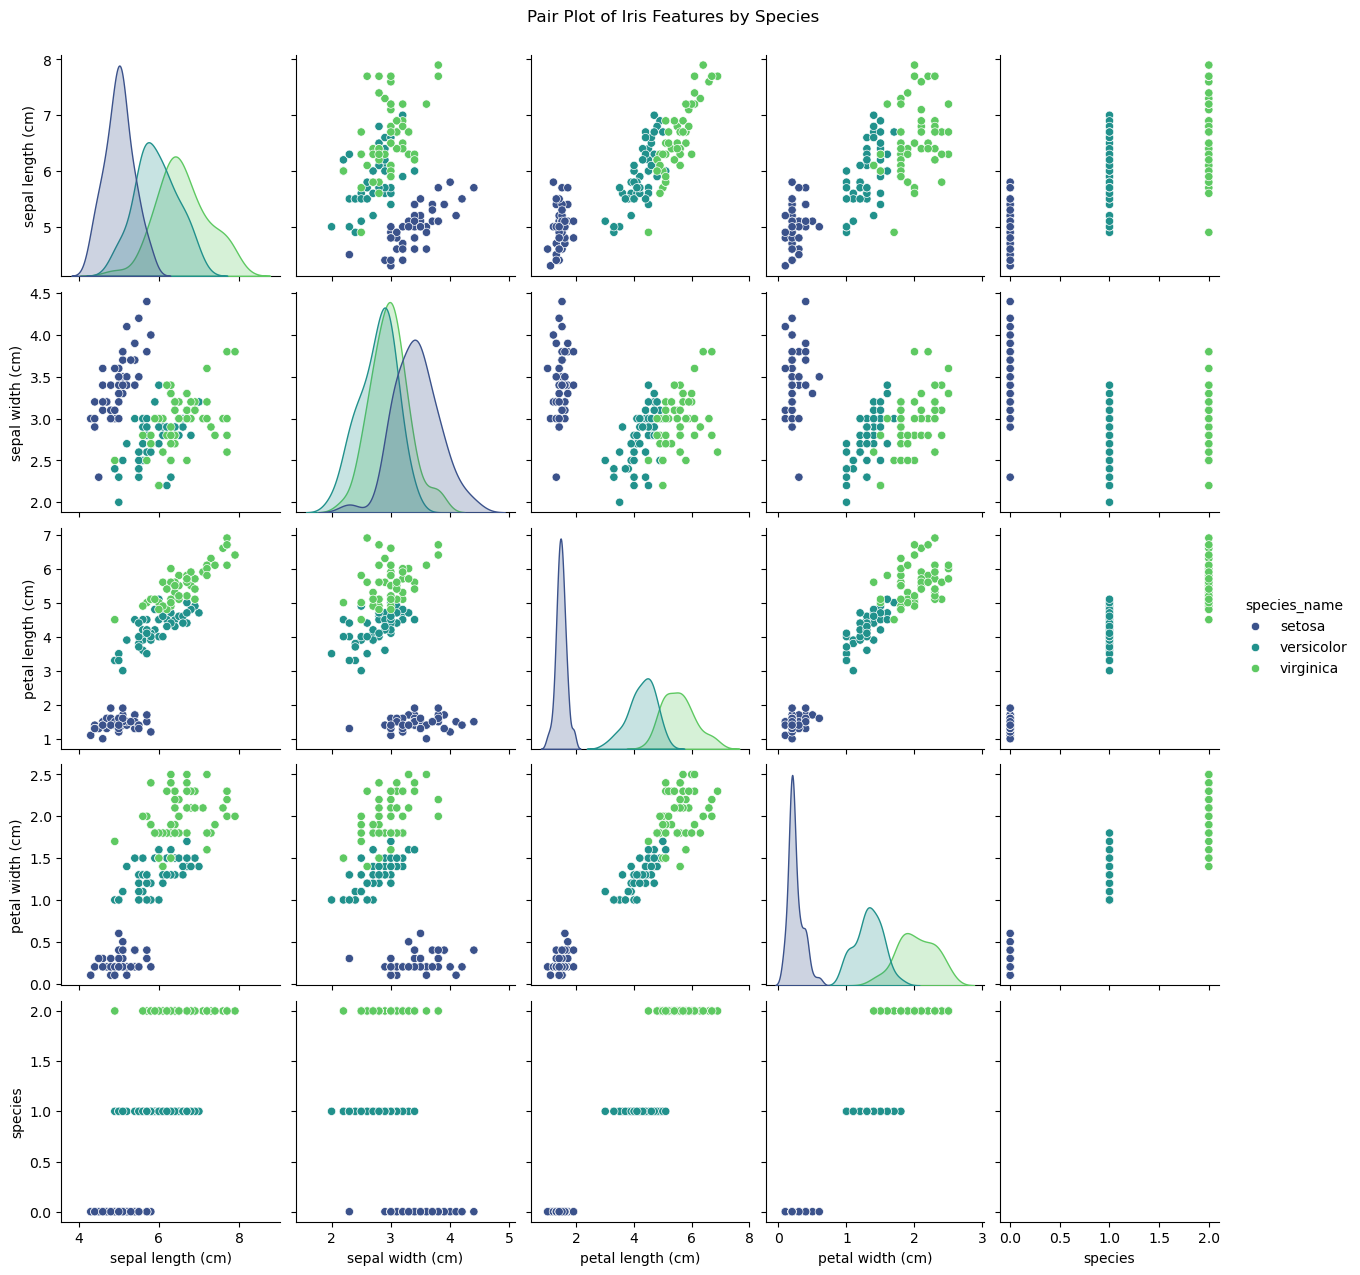

In [16]:

sns.pairplot(df, hue='species_name', palette='viridis')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust suptitle position
plt.show()

In [18]:
# d. Splitting Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")


Training set size: 120 samples
Testing set size: 30 samples


In [19]:
# e. Model Selection (Using K-Nearest Neighbors as an example)
model = KNeighborsClassifier(n_neighbors=3) # You can experiment with n_neighbors

In [20]:
# f. Model Training
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete.")


Training the model...
Model training complete.


In [21]:
# g. Model Evaluation
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))



--- Model Evaluation ---
Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
# h. Example of making a prediction on new, unseen data
# if we have a new flower with these measurements:
# sepal length=5.5, sepal width=2.5, petal length=4.0, petal width=1.3
new_flower_measurements = [[5.5, 2.5, 4.0, 1.3]]
predicted_species_index = model.predict(new_flower_measurements)
predicted_species_name = target_names[predicted_species_index[0]]

print(f"\nNew flower measurements: {new_flower_measurements[0]}")
print(f"Predicted species: {predicted_species_name}")


New flower measurements: [5.5, 2.5, 4.0, 1.3]
Predicted species: versicolor
